In [1]:
!pip install plotly folium --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
from google.colab import files
import io

uploaded = files.upload()  # Upload your CSV file here

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Saving road_accident_data.csv to road_accident_data.csv
✅ Dataset loaded: 1500 rows × 12 columns


In [4]:
print('🔢 Shape:', df.shape)
print('\n📋 Columns:\n', df.columns.tolist())
df.head()

🔢 Shape: (1500, 12)

📋 Columns:
 ['Date', 'Accident_Severity', 'Weather_Conditions', 'Road_Surface_Conditions', 'Light_Conditions', 'Vehicle_Type', 'Road_Type', 'Speed_limit', 'Number_of_Casualties', 'Number_of_Vehicles', 'Latitude', 'Longitude']


,Date,Accident_Severity,Weather_Conditions,Road_Surface_Conditions,Light_Conditions,Vehicle_Type,Road_Type,Speed_limit,Number_of_Casualties,Number_of_Vehicles,Latitude,Longitude
0,2015-01-01 00:00:00.000000,Slight,Fine no high winds,Wet or damp,Daylight,Motorcycle,Single carriageway,70,1,2,56.2279,-3.2465
1,2015-01-02 22:46:01.841227,Fatal,Fine no high winds,Wet or damp,Daylight,Car,Roundabout,40,4,1,50.4510,-0.8917
2,2015-01-04 21:32:03.682454,Serious,Fine no high winds,Dry,Daylight,Goods vehicle,Single carriageway,60,3,1,54.2005,-0.5425
3,2015-01-06 20:18:05.523682,Slight,Fine no high winds,Wet or damp,Daylight,Motorcycle,Single carriageway,30,1,1,50.6670,0.7177
4,2015-01-08 19:04:07.364909,Slight,Fine no high winds,Wet or damp,Daylight,Car,Dual carriageway,50,1,2,56.6983,-0.9701


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Accident_Severity        1500 non-null   object 
 2   Weather_Conditions       1500 non-null   object 
 3   Road_Surface_Conditions  1500 non-null   object 
 4   Light_Conditions         1500 non-null   object 
 5   Vehicle_Type             1500 non-null   object 
 6   Road_Type                1500 non-null   object 
 7   Speed_limit              1500 non-null   int64  
 8   Number_of_Casualties     1500 non-null   int64  
 9   Number_of_Vehicles       1500 non-null   int64  
 10  Latitude                 1500 non-null   float64
 11  Longitude                1500 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 140.8+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,1500,1500,2022-12-31 00:00:00.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accident_Severity,1500,3,Slight,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather_Conditions,1500,7,Fine no high winds,828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road_Surface_Conditions,1500,5,Dry,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Light_Conditions,1500,5,Daylight,904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,1500,7,Car,873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road_Type,1500,5,Single carriageway,858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Speed_limit,1500.0,NaN,NaN,NaN,42.88,15.112617,20.0,30.0,40.0,60.0,70.0
Number_of_Casualties,1500.0,NaN,NaN,NaN,2.992,1.410885,1.0,2.0,3.0,4.0,5.0
Number_of_Vehicles,1500.0,NaN,NaN,NaN,1.996667,0.820429,1.0,1.0,2.0,3.0,3.0


In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('✅ No missing values found! Dataset is clean.')
else:
    print('🚨 Missing Values:')
    print(missing)
    plt.figure(figsize=(10, 4))
    missing.plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

✅ No missing values found! Dataset is clean.


In [8]:
df.dropna(thresh=int(0.7 * df.shape[1]), inplace=True)
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

date_cols = [c for c in df.columns if 'date' in c]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df['year'] = df[col].dt.year
    df['month'] = df[col].dt.month
    df['day_of_week'] = df[col].dt.day_name()
    df['hour'] = df[col].dt.hour

print('✅ Data cleaned successfully!')
print(f'Final shape: {df.shape}')

✅ Data cleaned successfully!
Final shape: (1500, 16)


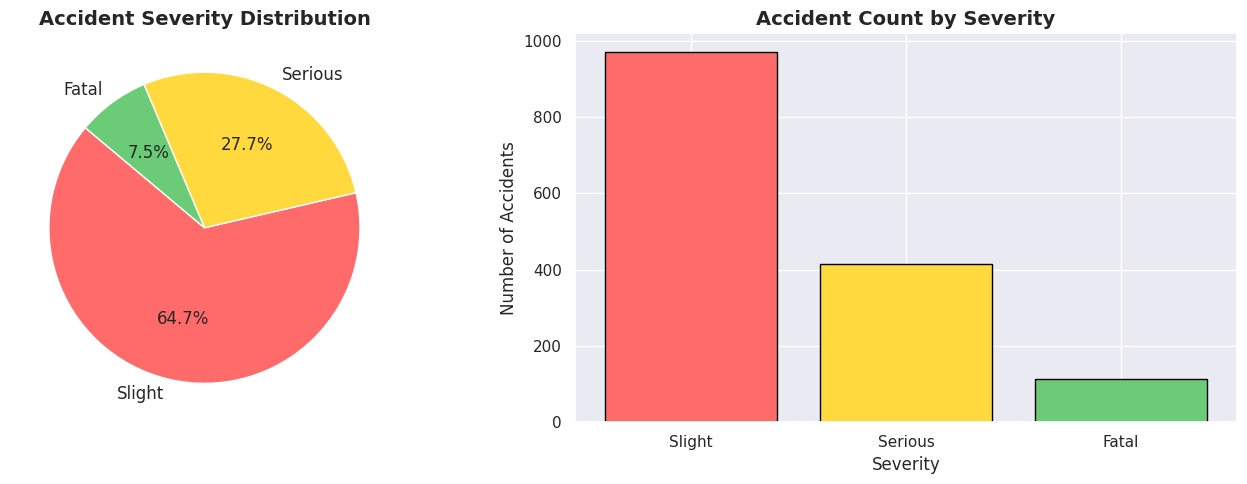

💡 Insight: Slight accidents are most common; Fatal accidents are the least.


In [9]:
severity_col = [c for c in df.columns if 'severity' in c][0]
severity_counts = df[severity_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#FFD93D', '#6BCB77']

axes[0].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[0].set_title('Accident Severity Distribution', fontsize=14, fontweight='bold')

axes[1].bar(severity_counts.index, severity_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Accident Count by Severity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Number of Accidents')

plt.tight_layout()
plt.show()
print('💡 Insight: Slight accidents are most common; Fatal accidents are the least.')

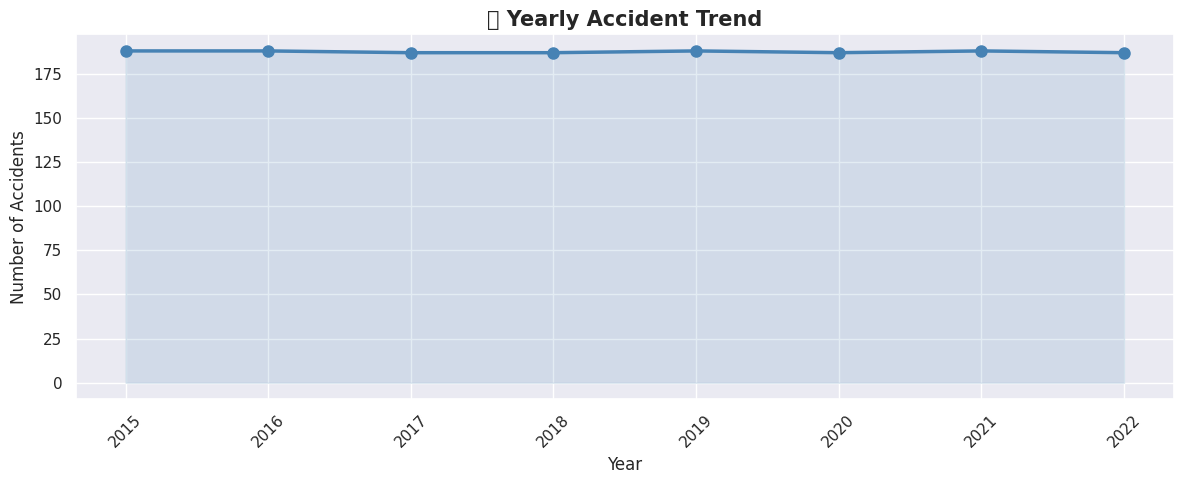

💡 Insight: Observe whether accidents are increasing or decreasing over time.


In [10]:
yearly = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue',
         linewidth=2.5, markersize=8)
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
plt.title('📈 Yearly Accident Trend', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(yearly.index, rotation=45)
plt.tight_layout()
plt.show()
print('💡 Insight: Observe whether accidents are increasing or decreasing over time.')

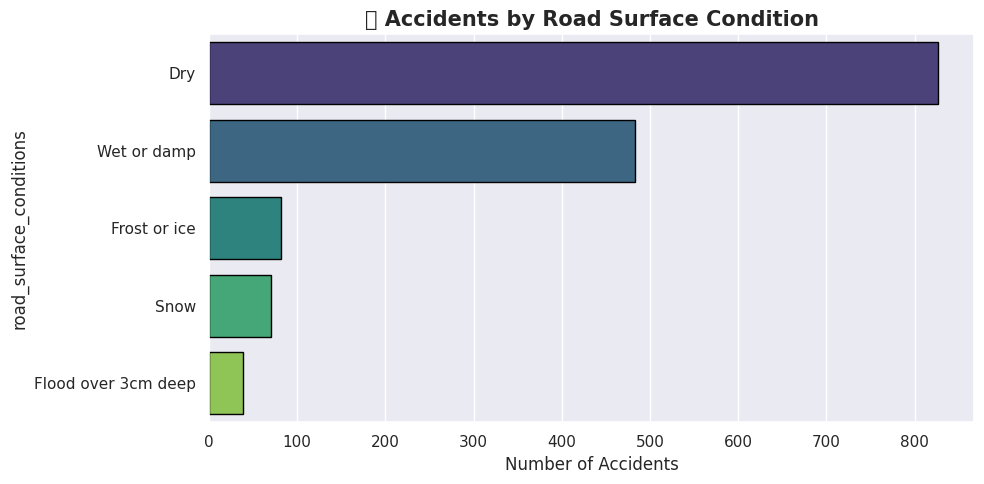

In [11]:
road_col = [c for c in df.columns if 'road_surface' in c or 'surface' in c][0]
road_counts = df[road_col].value_counts().head(6)

plt.figure(figsize=(10, 5))
sns.barplot(x=road_counts.values, y=road_counts.index,
            palette='viridis', edgecolor='black')
plt.title('🛣️ Accidents by Road Surface Condition', fontsize=15, fontweight='bold')
plt.xlabel('Number of Accidents')
plt.tight_layout()
plt.show()

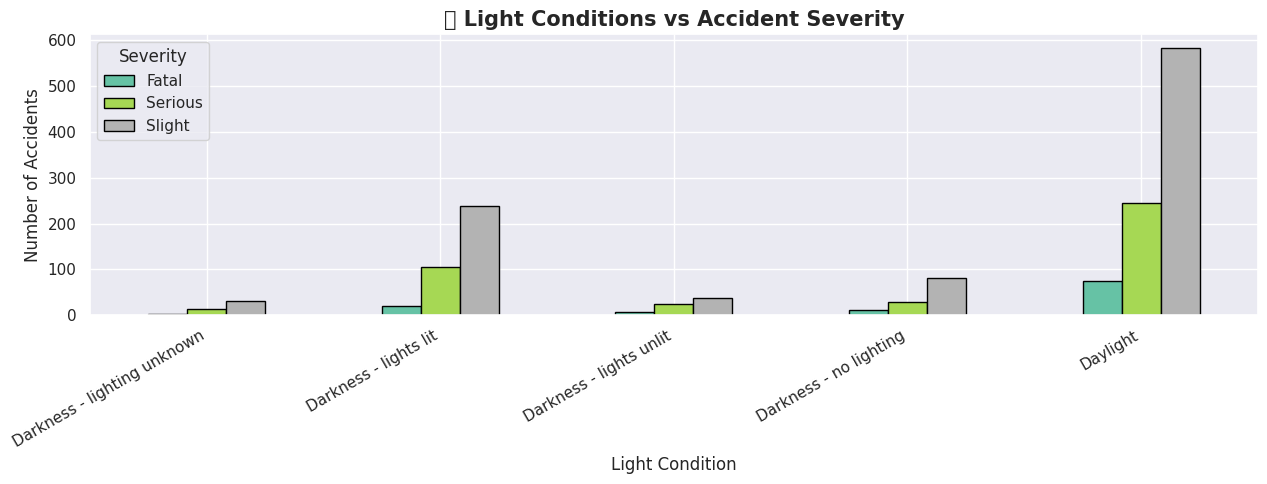

In [12]:
light_col = [c for c in df.columns if 'light' in c][0]
light_sev = df.groupby([light_col, severity_col]).size().unstack(fill_value=0)

light_sev.plot(kind='bar', figsize=(13, 5), colormap='Set2', edgecolor='black')
plt.title('💡 Light Conditions vs Accident Severity', fontsize=15, fontweight='bold')
plt.xlabel('Light Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

In [13]:
vehicle_col = [c for c in df.columns if 'vehicle' in c and 'type' in c][0]
vehicle_counts = df[vehicle_col].value_counts().head(8)

fig = px.bar(x=vehicle_counts.index, y=vehicle_counts.values,
             color=vehicle_counts.values, color_continuous_scale='Reds',
             labels={'x': 'Vehicle Type', 'y': 'Accidents'},
             title='🚙 Top Vehicle Types Involved in Accidents')
fig.update_layout(showlegend=False)
fig.show()
print('💡 Insight: Cars are the most frequently involved vehicle type.')

💡 Insight: Cars are the most frequently involved vehicle type.


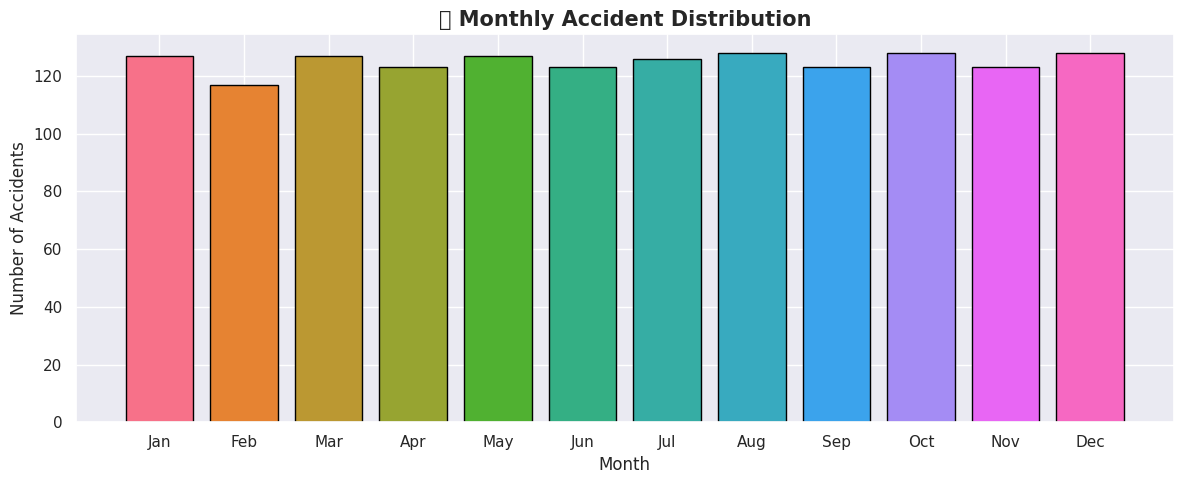

💡 Insight: Winter months (Oct–Dec) tend to have higher accident rates.


In [14]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df['month'].value_counts().sort_index()
monthly.index = [month_names[m] for m in monthly.index]

plt.figure(figsize=(12, 5))
plt.bar(monthly.index, monthly.values,
        color=sns.color_palette('husl', 12), edgecolor='black')
plt.title('📅 Monthly Accident Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()
print('💡 Insight: Winter months (Oct–Dec) tend to have higher accident rates.')

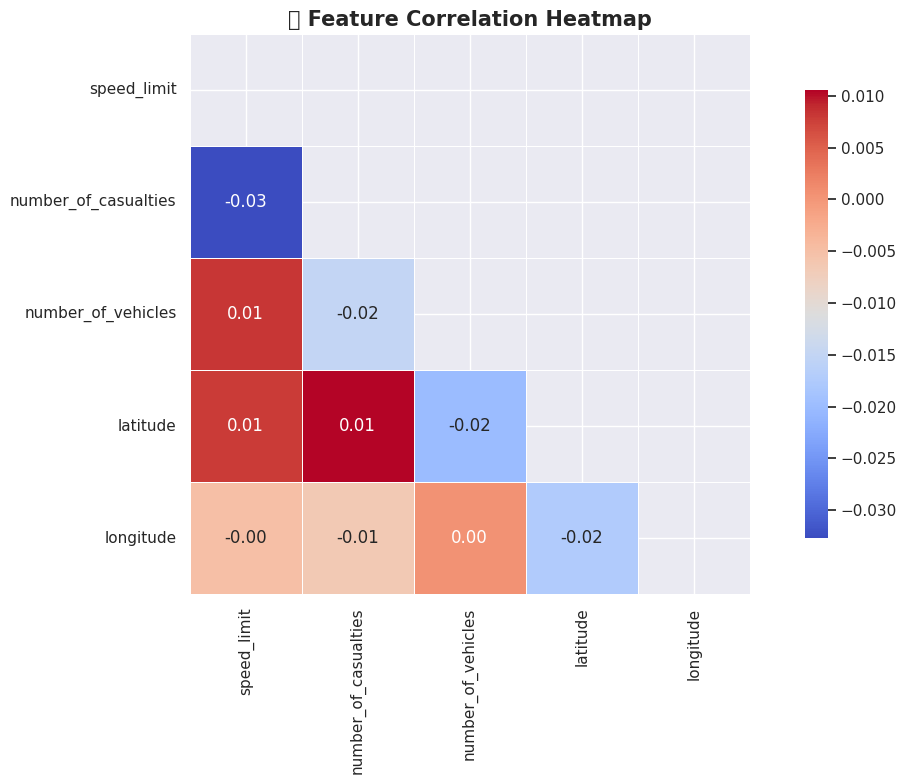

In [15]:
num_df = df.select_dtypes(include='number').drop(columns=['year','month','hour'], errors='ignore')
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('🔗 Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print('='*60)
print('🚗 ROAD ACCIDENT ANALYSIS — KEY INSIGHTS')
print('='*60)
print(f'\n📌 Total Records Analyzed : {df.shape[0]:,}')
print(f'📌 Total Features         : {df.shape[1]}')
print(f'📌 Year Range             : {int(df["year"].min())} – {int(df["year"].max())}')

top_severity = df[severity_col].value_counts().idxmax()
print(f'📌 Most Common Severity   : {top_severity}')

top_day = df['day_of_week'].value_counts().idxmax()
print(f'📌 Most Accident-Prone Day: {top_day}')

top_hour = df['hour'].value_counts().idxmax()
print(f'📌 Peak Accident Hour     : {top_hour}:00')

print('\n✅ Analysis Complete!')
print('='*60)

🚗 ROAD ACCIDENT ANALYSIS — KEY INSIGHTS

📌 Total Records Analyzed : 1,500
📌 Total Features         : 16
📌 Year Range             : 2015 – 2022
📌 Most Common Severity   : Slight
📌 Most Accident-Prone Day: Thursday
📌 Peak Accident Hour     : 0:00

✅ Analysis Complete!
